# Fine-tuning do modelo com LoRA

Este notebook transforma o corpus preparado em um adaptador para o modelo FLAN-T5-small. O modelo base consegue lidar com texto em sentido amplo, mas não conhece o formato específico dos documentos sintéticos deste projeto. O fine-tuning apresenta exemplos de solicitação, contexto e resposta para aproximar o comportamento do modelo desse formato.

O ambiente local possui memória limitada e não utiliza GPU. Por isso, o treinamento usa LoRA. Em vez de alterar todos os pesos do modelo, a técnica adiciona componentes pequenos e treináveis aos mecanismos de atenção, mantendo o restante congelado. Essa escolha reduz o consumo de memória e permite salvar o resultado como um adaptador separado.

O notebook verifica o ambiente, executa ou lê o treinamento e apresenta os registros produzidos. A intenção é mostrar o procedimento e seus limites, não tratar o modelo como uma ferramenta clínica pronta.

In [1]:
from pathlib import Path
import json, os, sys
import warnings

warnings.filterwarnings("ignore", message="IProgress not found.*", module="tqdm.auto")
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(ROOT)
sys.path.insert(0, str(ROOT / "src"))
os.environ["HF_HOME"] = str(ROOT / ".hf-cache")
import torch
from importlib.metadata import version
print({n: version(n) for n in ("torch","transformers","peft")})
print("CUDA:", torch.cuda.is_available())
RUN_TRAINING = not (ROOT / "docs/results/training.json").exists()

{'torch': '2.7.1', 'transformers': '4.51.3', 'peft': '0.15.2'}
CUDA: False


## Como o texto é preparado para o modelo

Modelos de linguagem não recebem palavras diretamente. A tokenização converte o prompt e a resposta em unidades numéricas reconhecidas pelo modelo. Antes de treinar, o programa mede todos os exemplos. Se algum texto ultrapassar o limite definido, a execução é interrompida para revisão. Nenhum trecho é removido sem aviso.

O formato de prompt é compartilhado pelo treinamento e pela aplicação. Assim, o adaptador aprende a responder a uma estrutura composta por instrução de segurança, pergunta e evidências. Usar a mesma estrutura depois da implantação evita que o modelo receba uma entrada diferente daquela vista durante o ajuste.

A perda registrada indica o quanto as previsões se aproximam das respostas de referência. Ela é útil para escolher entre versões do adaptador, mas não mede segurança, factualidade ou utilidade clínica.

In [2]:
from clinical_assistant.training import run
if RUN_TRAINING:
    run(ROOT, epochs=6)
result_path = ROOT / "docs/results/training.json"
if not result_path.exists():
    raise FileNotFoundError("Execute python -m clinical_assistant.training antes de analisar os resultados.")
result = json.loads(result_path.read_text(encoding="utf-8"))
print("Execução registrada:", result["timestamp_utc"])
print("Modelo:", result["model"], "revisão:", result["model_revision"])
print("Parâmetros treináveis:", result["trainable_parameters"])
print("Proporção:", result["trainable_parameters"] / result["total_parameters"])
print("Comprimentos:", result["token_lengths"])

Passing a tuple of `past_key_values` is deprecated and will be removed in Transformers v4.48.0. You should pass an instance of `EncoderDecoderCache` instead, e.g. `past_key_values=EncoderDecoderCache.from_legacy_cache(past_key_values)`.


{"epoch": 1, "train_loss": 3.837281004587809, "validation_loss": 3.1189650535583495}
{"epoch": 2, "train_loss": 3.780965010325114, "validation_loss": 3.0937588691711424}
{"epoch": 3, "train_loss": 3.758348735173543, "validation_loss": 3.061461877822876}
{"epoch": 4, "train_loss": 3.7387876669565836, "validation_loss": 3.025397539138794}
{"epoch": 5, "train_loss": 3.6666372617085776, "validation_loss": 2.987734317779541}
{"epoch": 6, "train_loss": 3.6724612077077228, "validation_loss": 2.949735927581787}
Execução registrada: 2026-09-15T14:44:38.142689+00:00
Modelo: google/flan-t5-small revisão: 0fc9ddf78a1e988dac52e2dac162b0ede4fd74ab
Parâmetros treináveis: 344064
Proporção: 0.00445072166928555
Comprimentos: {'train': {'max_input': 184, 'max_target': 153}, 'validation': {'max_input': 172, 'max_target': 97}, 'test': {'max_input': 155, 'max_target': 109}}


## Execução e evidências locais

A variável RUN_TRAINING é definida automaticamente. Quando não existe resultado local, o notebook inicia o treinamento. Quando já existe, ele apenas lê os arquivos para evitar repetir uma operação demorada. A variável pode ser definida como True para forçar uma nova execução.

Em cada época, o programa percorre os exemplos de treino e depois consulta a partição de validação. A versão com melhor resultado de validação é salva como adaptador. Após essa escolha, o adaptador é recarregado e comparado ao modelo base usando somente os exemplos de teste.

O gráfico e o arquivo de resultados são gerados localmente.

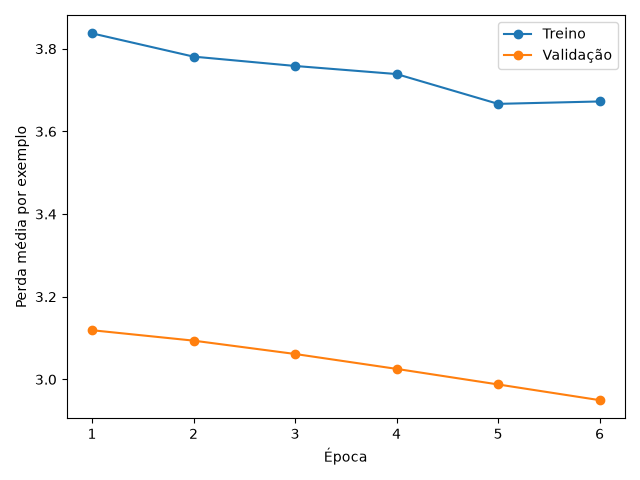

Época selecionada: 6
Perda no teste, base: 3.075344753265381
Perda no teste, adaptado: 2.904933738708496


In [3]:
from IPython.display import Image, display
display(Image(filename=str(ROOT / "docs/results/loss.png")))
print("Época selecionada:", result["selected_epoch"])
print("Perda no teste, base:", result["base_test_loss"])
print("Perda no teste, adaptado:", result["adapted_test_loss"])

## Como interpretar os resultados

Uma redução de perda mostra que o modelo se aproximou dos textos usados como referência. Isso não significa que sua resposta é correta, segura ou apropriada para uso clínico. Em uma amostra pequena, o modelo pode aprender padrões superficiais e ainda falhar ao explicar uma situação.

Por esse motivo, os números são acompanhados pela leitura das respostas. Repetição de instruções, cópia da pergunta, mistura de idiomas e conteúdo sem apoio nas evidências são sinais de limitação. O próximo notebook mostra o carregamento do adaptador com contexto; a avaliação compara as saídas de forma explícita.

O adaptador salvo comprova a execução do fine-tuning, mas não representa um modelo validado para atendimento.